In [22]:
import scipy as sp
from scipy.special import jv, hankel1, hankel2, yv, yvp, jvp
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, argmin, log, unravel_index, pi, array, einsum, angle
from utils import hl1_prime, hl2_prime, h_z_cpa_numerator, h_z_cpa, e_z_cpa, h_z_recursive_cpa, e_z_recursive_cpa

## Description of notebook:
Plot numbers below correspond to those in [Broadband subwavelength focusing of
light using a passive sink](https://opg.optica.org/oe/fulltext.cfm?uri=oe-21-15-17435). Note that this link may not work because Optica URLs are weird, so you may have to search by the paper title in scholar. 

In [61]:
m = 1 # angular momentum number under consideration
lambda_air = 532 # wavelength in air of the incident light in nm
R = 5.1 # Radius of the cylindrical scatterer
x = (2*pi/lambda_air)*R # kR
N = 10000
epsilons_m_1 = linspace(-1.02, -1, N) + 0j # The paper states that s=-1 at around -1.01 so we look around this region. Note that we have to add 0j
# to the dielectric function for numpy to not throw an error (dielectric function must be interpreted as a complex number). 
s_arr_m_1 = h_z_cpa(m, x, epsilons_m_1); # Scattering coefficients corresponding to m=1
m = 2 # angular momentum number under consideration
epsilons_m_2 = linspace(-1.001222, -1.0012, N) + 0j # The paper states that s=-1 at around -1.001, so we look around this region
s_arr_m_2 = h_z_cpa(m, x, epsilons_m_2); # Scattering coefficients corresponding to m=2

### The paper states that $s=-1$ for $\epsilon \approx -1.01$ for $m=1$ and $\epsilon \approx -1.001$ for $m=2$. We verify this in the below.

m = 1
Epsilon at which Re(s) is closest to -1:  -1.0116
Epsilon at which Im(s) is closest to 0:  -1.0116
m = 2
Epsilon at which Re(s) is closest to -1:  -1.0012
Epsilon at which Im(s) is closest to 0:  -1.0012


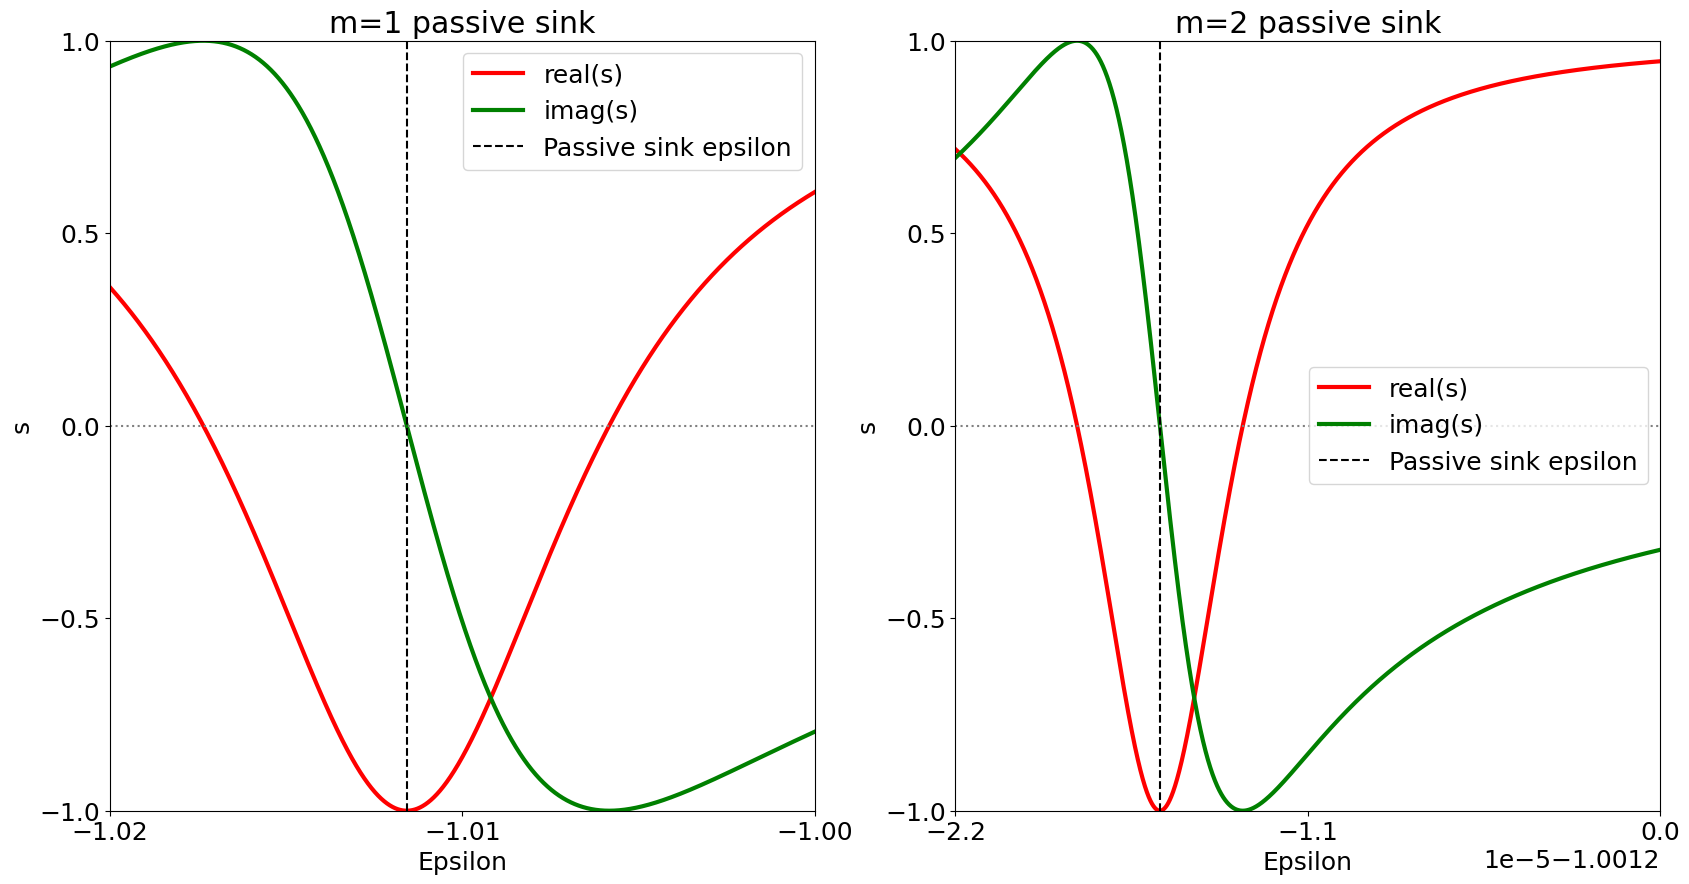

In [62]:
plt.rcParams.update({'font.size': 18})
linewidth=3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
for (m_idx, (epsilons, s_arr, ax)) in enumerate(zip((epsilons_m_1, epsilons_m_2), (s_arr_m_1, s_arr_m_2), (ax1, ax2))):
    real_epsilons = epsilons.real
    epsilon_min = real_epsilons.min()
    epsilon_max = real_epsilons.max()
    s_arr_real = s_arr.real
    s_arr_imag = s_arr.imag

    passive_sink_epsilon_1 = real_epsilons[np.abs(s_arr_real+1).argmin()]
    passive_sink_epsilon_2 = real_epsilons[np.abs(s_arr_imag).argmin()]
    
    ax.plot(real_epsilons, s_arr_real, label="real(s)", color="red", linewidth=linewidth)
    ax.plot(real_epsilons, s_arr_imag, label="imag(s)", color="green", linewidth=linewidth)
    ax.set_xlim(epsilon_min, epsilon_max);
    ax.set_ylim(-1, 1); # Since we have no loss or gain, we know that |s|=1 throughout, so this is an appropriate range. 
    ax.set_xticks([epsilon_min, (epsilon_min+epsilon_max)/2,  epsilon_max])
    ax.set_yticks(linspace(-1, 1, 5))
    ax.set_xlabel("Epsilon")
    ax.set_ylabel("s")
    print(f"m = {m_idx + 1}")
    print("Epsilon at which Re(s) is closest to -1: ", passive_sink_epsilon_1.round(4))
    print("Epsilon at which Im(s) is closest to 0: ", passive_sink_epsilon_2.round(4))

    ax.vlines([passive_sink_epsilon_1], -1, 1, color="black", label="Passive sink epsilon", linestyle="dashed")
    ax.hlines([0], epsilon_min, epsilon_max, color="grey", linestyle="dotted")
    ax.legend();
    ax.set_title(f"m={m_idx + 1} passive sink");

## Figure 4a (We return to 4b later in the notebook)
We fix the real part of the dielectric constant of the scatterer to that corresponding to the passive sink ($s=-1$). We then sweep the imaginary part of the dielectric constant from $0.00$ to $0.10$, corresponding to finite loss. We naturally expect that, in this region of phase space, $|s|<1$ since some of the incident energy will be absorbed.

In [65]:
passive_sink_idx = np.abs(s_arr_m_1.real+1).argmin() # index corresponding to the s closest to -1
re_epsilon = epsilons_m_1[passive_sink_idx].real
N = 10000
m = 1
epsilons_4_a = re_epsilon + 1j*linspace(0, 0.01, N)
s_arr_4_a = h_z_cpa(m, x, epsilons_4_a); # Scattering amplitudes as we sweep the imaginary part of the dielectric constant. 

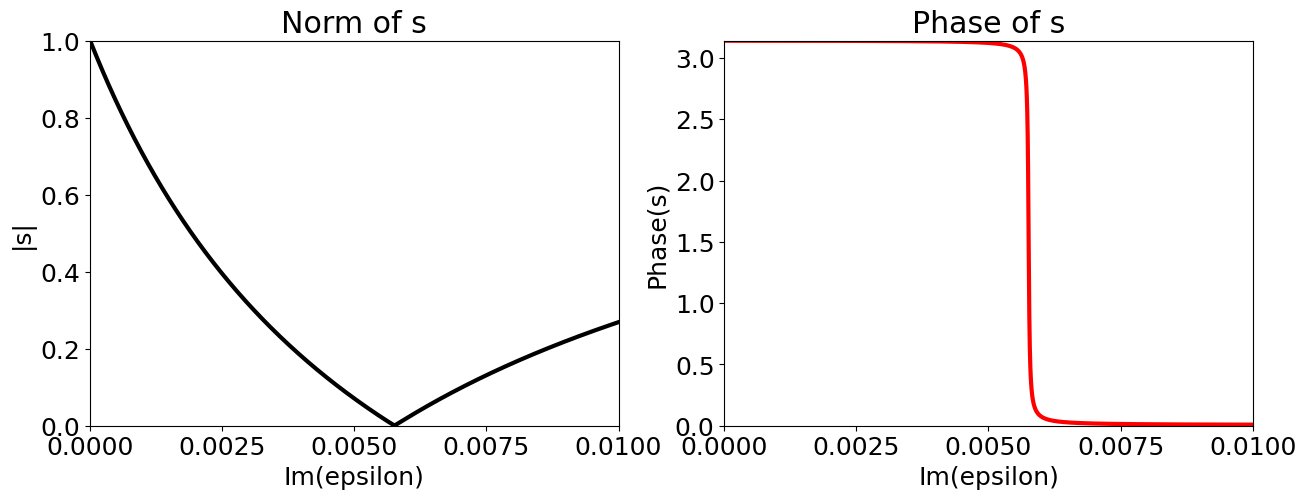

In [67]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
linewidth=3
epsilons_4_a_imag = epsilons_4_a.imag
ax1.plot(epsilons_4_a_imag, np.abs(s_arr_4_a), color="black", linewidth=linewidth)
ax1.set_xlim(epsilons_4_a_imag.min(), epsilons_4_a_imag.max())
ax1.set_ylim(0, 1)
ax1.set_xlabel("Im(epsilon)")
ax1.set_ylabel("|s|")
ax1.set_title("Norm of s")
ax2.plot(epsilons_4_a_imag, angle(s_arr_4_a), color="red", linewidth=linewidth)
ax2.set_xlim(epsilons_4_a_imag.min(), epsilons_4_a_imag.max())
ax1.set_xticks(linspace(0, 0.01, 5));
ax2.set_xticks(linspace(0, 0.01, 5));
ax2.set_ylim(0, pi);
ax2.set_xlabel("Im(epsilon)")
ax2.set_ylabel("Phase(s)")
ax2.set_title("Phase of s");

## Figure 2

### We first make the linear scale plots (2a, 2c)

Note that, in the below, we define functions that retrieve the electric field. These functions do so up to an overall factor of $i/\omega$. This is unimportant since we scale everything to the values in vacuum at the same frequency. It's unclear whether the paper's definition of intensity is $\varepsilon(\omega)|E|^2$ or simply $|E|^2$, but since $|\varepsilon(\omega)|\approx 1$, this doesn't seem to matter too much. 

In [69]:
# Electric field in vacuum (s=1, which means we only have a Bessel function of the first kind)
def E_vacuum(m, lambda_air, r):
    k = (2*pi/lambda_air)
    kr = k*r
    return (1j*m/r)*jv(m, kr), -k*jvp(m, kr) # E_rho, E_theta
# Electric field for a passive sink scatterer (for r>R) (s=-1 so we only have a Bessel function of the second kind outside the scatterer
def E_scatterer_gt(m, lambda_air, r):
    k = (2*pi/lambda_air)
    kr = k*r
    return (1j*m/r)*yv(m, kr), -k*yvp(m, kr)
# Electric field in the azimuthal direction (for r<R) (although s=-1, we must have a non-diverging field for r<R at the origin, which means 
# we require a Bessel function of the   
def E_scatterer_lt(m, lambda_air, r, R, epsilon):
    n = sqrt(epsilon)
    k = (2*pi/lambda_air)
    kr = k*r
    kR = k*R
    return (1j*m/r)*jv(m, n*kr)*yv(m, kR)/jv(m, n*kR)/epsilon, -n*k*jvp(m, n*kr)*yv(m, k*R)/jv(m, n*kR)/epsilon # E_rho, E_theta
def E_scatterer(m, lambda_air, r, R, epsilon):
    return np.where(r<R, E_scatterer_lt(m, lambda_air, r, R, epsilon), E_scatterer_gt(m, lambda_air, r))

### The functions above are for $s=1$ and $s=-1$, respectively, for vacuum and scatterer. Functions for general $s$ are defined later. Note that for $s=-1$, we have that $nJ_m(nkR){H_m}^{'2}(kR)-J'_m(nkR)H_m^2(kR)=nJ_m(nkR){H_m}^{'1}(kR)-J'_m(nkR)H_m^1(kR)$, which may be equivalently written as $nJ_m(nkR){Y_m}^{'}(kR)-J'_m(nkR)Y_m(kR)=0\rightarrow {Y_m}^{'}(kR)=J'_m(nkR)Y_m(kR)/nJ_m(nkR)$. Using this identity, we see that the tangential component of the electric field, defined above, is continuous (as is the normal component of the diplacement field, but that follows more easily). 

In [70]:
lambda_air = 532 # wavelength in air in nm
R = 5.1 # Radius of the cylindrical scatterer
N = 10000
rs_vacuum = linspace(0.1, 180, N)
rs_scatterer = linspace(0.1, 180, N)

In [71]:
vacuum_intensities = []
scatterer_intensities = []
ms = [1, 2]
epsilon = -1 + 0j
for m in ms:
    E_vacuum_rho, E_vacuum_theta = E_vacuum(m, lambda_air, rs_vacuum)
    E_scatterer_rho, E_scatterer_theta = E_scatterer(m, lambda_air, rs_scatterer, R, epsilon)

    vacuum_intensity = np.abs(E_vacuum_rho)**2 + np.abs(E_vacuum_theta)**2;
    scatterer_intensity = np.abs(E_scatterer_rho)**2 + np.abs(E_scatterer_theta)**2;
    vacuum_intensities.append(vacuum_intensity)
    scatterer_intensities.append(scatterer_intensity)

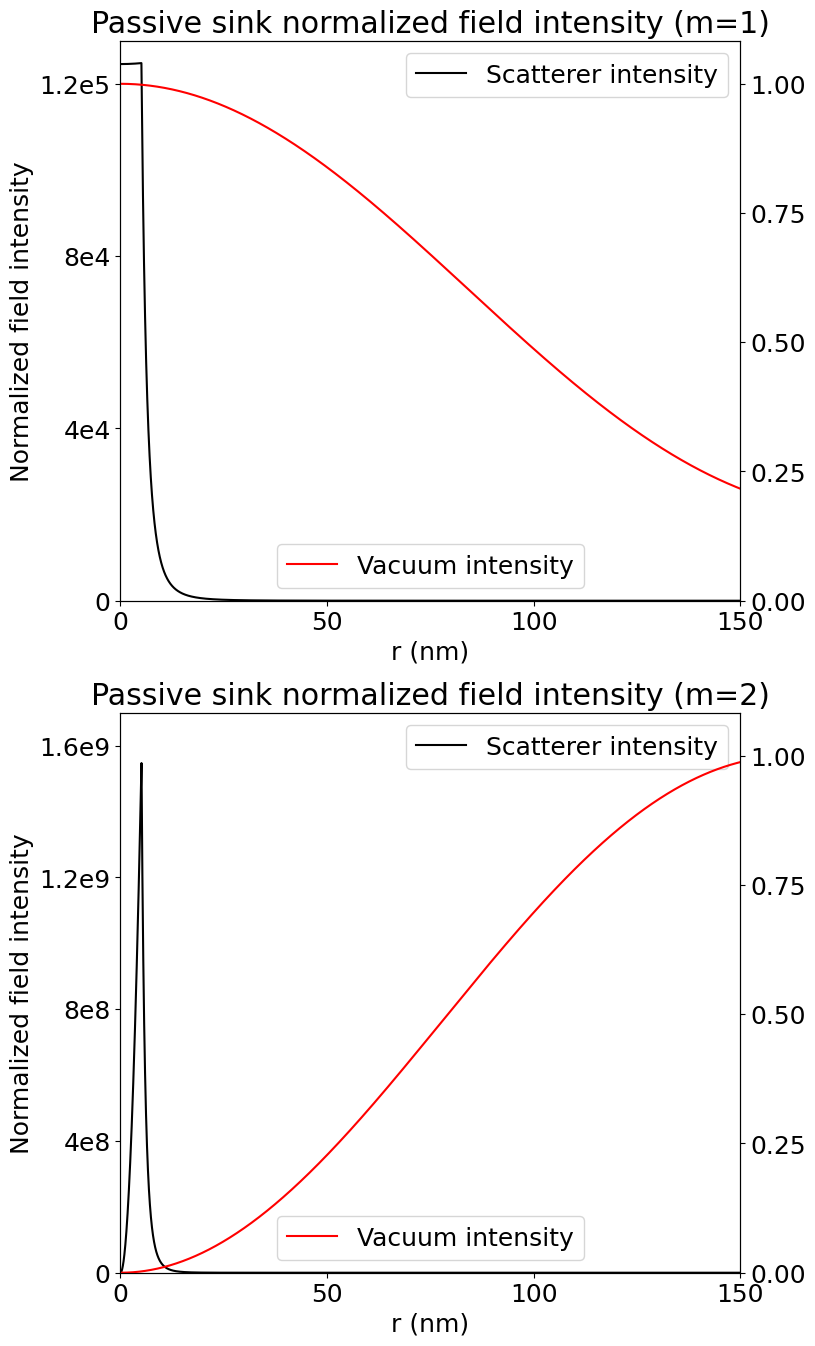

In [80]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 16))
for (ax_idx, ax) in enumerate((ax1, ax2)):
    vacuum_intensity = vacuum_intensities[ax_idx]
    scatterer_intensity = scatterer_intensities[ax_idx]
    max_vacuum_intensity = vacuum_intensity.max()
    m = ms[ax_idx]
    ax_twin = ax.twinx()
    ax.plot(rs_scatterer, scatterer_intensity/max_vacuum_intensity, color="black", label="Scatterer intensity")
    ax_twin.plot(rs_vacuum, vacuum_intensity/max_vacuum_intensity, color="red", label="Vacuum intensity")
    ax.set_xlim(0, 150)
    ax_twin.set_ylim(0, 1.083333)
    if ax_idx == 0:
        ax.set_yticks([0, 4e4, 8e4, 1.2e5], ["0", "4e4", "8e4", "1.2e5"])
        ax.set_ylim(0, 1.3e5)
    else: 
        ax.set_yticks([0, 4e8, 8e8, 1.2e9, 1.6e9], ["0", "4e8", "8e8", "1.2e9", "1.6e9"])
        ax.set_ylim(0, 1.7e9)
    ax_twin.set_yticks(linspace(0, 1, 5));
    ax.set_xticks(linspace(0, 150, 4));
    ax.set_xlabel("r (nm)");
    ax.set_ylabel("Normalized field intensity");
    ax.legend(loc=1)
    ax_twin.legend(loc=8)
    ax.set_title(f"Passive sink normalized field intensity (m={m})");

## Now we make the log plots (2b, 2d)

In [84]:
lambda_air = 532 # wavelength in air in nm
R = 5.1 # Radius of the cylindrical scatterer
N = 10000
rs_vacuum = linspace(0.1, 350, N)
rs_scatterer = linspace(0.1, 350, N)

In [85]:
vacuum_intensities = []
scatterer_intensities = []
ms = [1, 2]
for m in ms:
    E_vacuum_rho, E_vacuum_theta = E_vacuum(m, lambda_air, rs_vacuum)
    E_scatterer_rho, E_scatterer_theta = E_scatterer(m, lambda_air, rs_scatterer, R, epsilon)

    vacuum_intensity = np.abs(E_vacuum_rho)**2 + np.abs(E_vacuum_theta)**2;
    scatterer_intensity = np.abs(E_scatterer_rho)**2 + np.abs(E_scatterer_theta)**2;
    vacuum_intensities.append(vacuum_intensity)
    scatterer_intensities.append(scatterer_intensity)

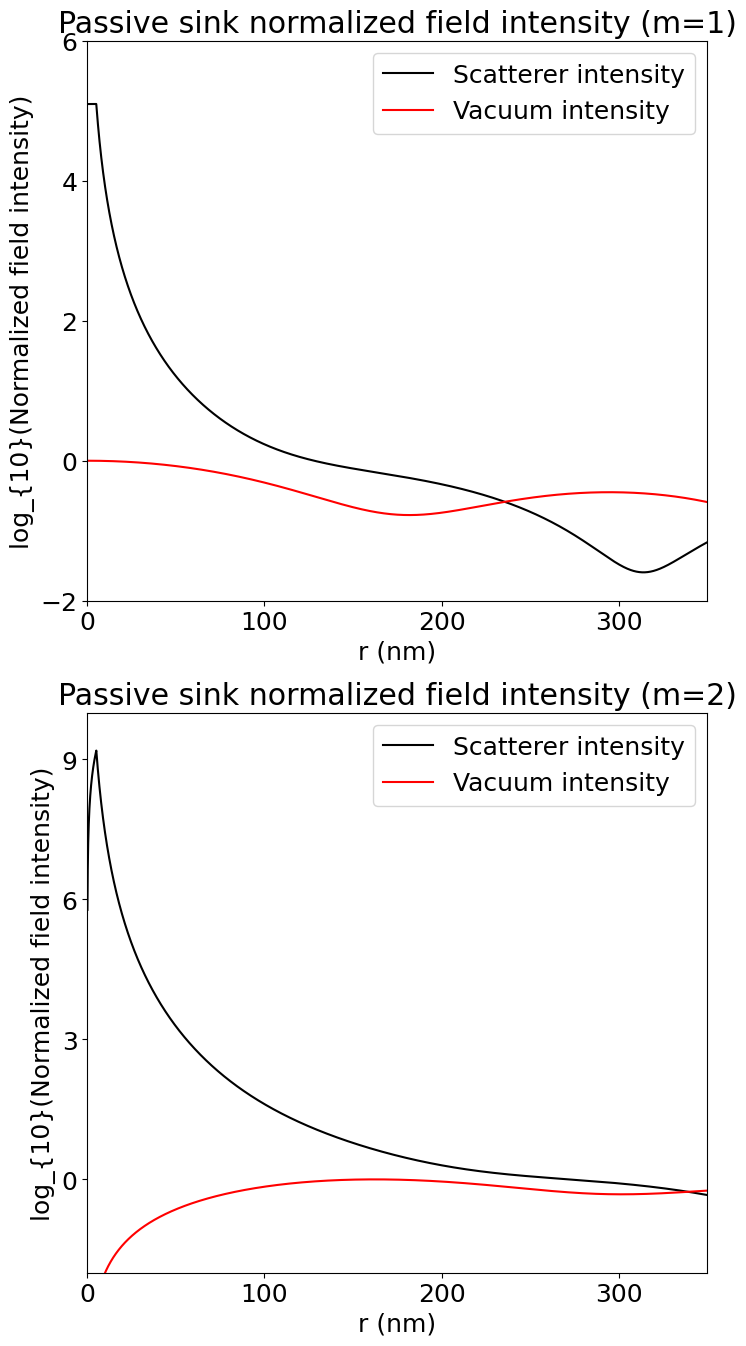

In [91]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 16))
for (ax_idx, ax) in enumerate((ax1, ax2)):
    vacuum_intensity = vacuum_intensities[ax_idx]
    scatterer_intensity = scatterer_intensities[ax_idx]
    max_vacuum_intensity = vacuum_intensity.max()
    m = ms[ax_idx]
    ax.plot(rs_scatterer, np.log10(scatterer_intensity/max_vacuum_intensity), color="black", label="Scatterer intensity")
    ax.plot(rs_vacuum, np.log10(vacuum_intensity/max_vacuum_intensity), color="red", label="Vacuum intensity")
    ax.set_xlim(0, 350)
    if ax_idx == 0:
        ax.set_yticks(linspace(-2, 6, 5))
        ax.set_ylim(-2, 6)
        #ax_twin.set_ylim(-2, 6)
    else: 
        ax.set_yticks(linspace(0, 9, 4))
        ax.set_ylim(-2, 10)
    ax.set_xticks(linspace(0, 300, 4));
    ax.set_xlabel("r (nm)");
    ax.legend()
    ax.set_ylabel("log_{10}(Normalized field intensity)");
    ax.set_title(f"Passive sink normalized field intensity (m={m})");

# Figure 3: Sweep of Re(epsilon)

Since we fix the imaginary part of the dielectric constant to zero, we expect $|s|=1$ throughout. 

In [93]:
N = 10000
m = 1
epsilons_3_a = linspace(-1.2, -0.8, N) + 0j
lambda_air = 532 # wavelength in air in nm
R = 5.1 # Radius of the cylindrical scatterer
x = (2*pi/lambda_air)*R # kR
s_arr_3_a = h_z_cpa(m, x, epsilons_3_a);

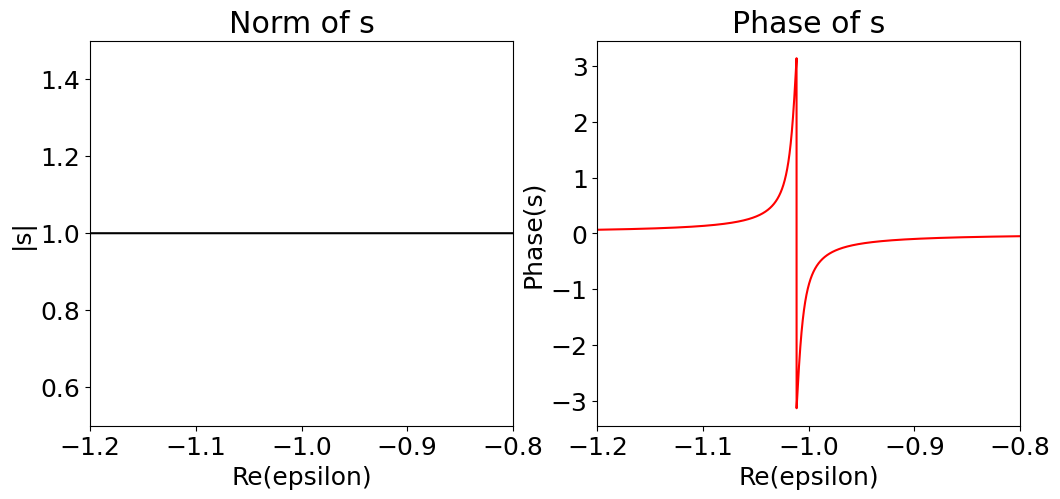

In [94]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(epsilons_3_a.real, np.abs(s_arr_3_a), color="black")
ax1.set_xlim(epsilons_3_a.real.min(), epsilons_3_a.real.max())
ax1.set_ylim(0.5, 1.5)
ax1.set_xlabel("Re(epsilon)")
ax1.set_ylabel("|s|")
ax1.set_title("Norm of s")
ax2.plot(epsilons_3_a.real, np.angle(s_arr_3_a), color="red")
ax2.set_xlim(epsilons_3_a.real.min(), epsilons_3_a.real.max())
#ax2.set_ylim(0, np.pi);
ax2.set_xlabel("Re(epsilon)")
ax2.set_ylabel("Phase(s)")
ax2.set_title("Phase of s");

### We define a function that gives us the field in the presence of the scatterer if the scattering coefficient, $s$, is given. We use the scattering coefficients, as a function of $\Re(\epsilon)$, derived above, to plot the normalized maximal field intensity as the real part of the dielectric constant of the scatterer is varied. The function only gives us the field outside the scatterer, but this is sufficient since we only need the field at $r=R+$ for the figure (since we want the maximal value).

In [95]:
def E_scatterer_s(s, m, lambda_air, r):
    k = (2*pi/lambda_air)
    kr = k*r
    return (1j*m/r)*(hankel2(m, kr) + s*hankel1(m, kr))/2, -k*(hl2_prime(m, kr) + s*hl1_prime(m, kr))/2 # E_r, E_theta
    # We divide by 2 to be consistent with the vacuum electric field code

In [96]:
r = R 
epsilons_3_b = epsilons_3_a
E_vacuum_rho, E_vacuum_theta = E_vacuum(m, lambda_air, R)
E_scatterer_rho, E_scatterer_theta= E_scatterer_s(s_arr_3_a, m, lambda_air, r)
vacuum_intensity = np.abs(E_vacuum_rho)**2 + np.abs(E_vacuum_theta)**2;
scatterer_intensity = np.abs(E_scatterer_rho)**2 + np.abs(E_scatterer_theta)**2;
normalized_scatterer_intensity = scatterer_intensity/vacuum_intensity

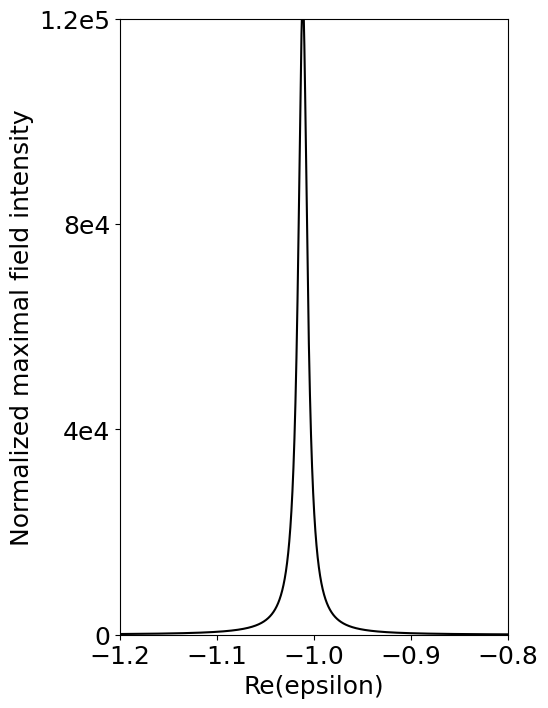

In [97]:
fig, ax = plt.subplots(figsize=(5, 8))
plt.plot(epsilons_3_b.real, normalized_scatterer_intensity, color="black")
ax.set_xlim(epsilons_3_b.real.min(), epsilons_3_b.real.max());
ax.set_xlabel("Re(epsilon)");
ax.set_ylabel("Normalized maximal field intensity")
ax.set_ylim(0, 1.2e5)
ax.set_yticks(linspace(0, 1.2e5, 4), ["0", "4e4", "8e4", "1.2e5"]);

In [98]:
epsilons_4_b = epsilons_4_a
s_arr_4_b = s_arr_4_a 
E_vacuum_rho, E_vacuum_theta = E_vacuum(m, lambda_air, R)
E_scatterer_rho, E_scatterer_theta = E_scatterer_s(s_arr_4_b, m, lambda_air, r)

vacuum_intensity = np.abs(E_vacuum_rho)**2 + np.abs(E_vacuum_theta)**2;
scatterer_intensity = np.abs(E_scatterer_rho)**2 + np.abs(E_scatterer_theta)**2;
normalized_scatterer_intensity = scatterer_intensity/vacuum_intensity

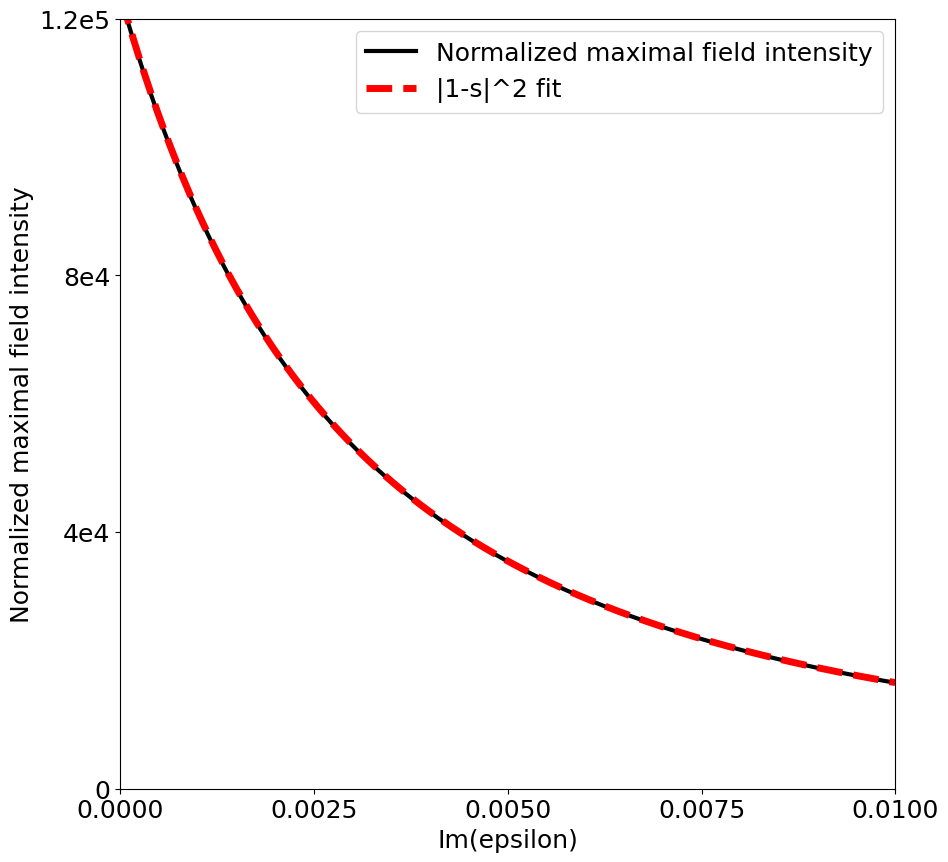

In [101]:
fig, ax = plt.subplots(figsize=(10, 10))
plt.plot(epsilons_4_b.imag, normalized_scatterer_intensity, color="black", linewidth=3, label="Normalized maximal field intensity")
plt.plot(epsilons_4_b.imag, 3.095e4*np.abs(1-s_arr_4_b)**2, color="red", linestyle="dashed", linewidth=5, label="|1-s|^2 fit")
ax.set_xlim(epsilons_4_b.imag.min(), epsilons_4_b.imag.max());
ax.set_xlabel("Im(epsilon)");
ax.set_ylabel("Normalized maximal field intensity")
ax.set_ylim(0, 1.2e5)
ax.set_yticks(linspace(0, 1.2e5, 4), ["0", "4e4", "8e4", "1.2e5"]);
ax.legend();
ax.set_xticks(linspace(0, 0.01, 5));

### Note that the paper has $\alpha=6.19e4$, but this seems like a typo to me since the fit is clearly correct for $\alpha\rightarrow\alpha/2$